# TAM demo

Minimal example: run `TAMExplainer` on a single image, print the generated caption, and display the saved per-token activation maps.

In [1]:
import tamart  # must come before any transformers import (sets HF_HOME)
from tamart.tam import TAMExplainer

explainer = TAMExplainer()

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


## Interactive viewer

Click a token below the image to see its activation map. Tweak colormap / alpha / value range to inspect what the map actually contains — useful when joint normalization with text scores squashes the image into the low end of the colormap. "Auto-fit range" snaps the slider to the current token's `(min, max)`.

In [2]:
result = explainer.explain_interactive(
    image="../data/datasets/wikiart_most_viewed/images/0003_in-bed-the-kiss-1892.jpg",
    prompt=(
        "Who made this artwork? Respond with a single JSON object and nothing "
        'else, in this exact shape: {"artist": "<the artist full name>"}.'
    ),
)

HTML(value='<b>Generated:</b> {"artist": "Henri de Toulouse-Lautrec"}')

## Top-pixel masking experiment

After selecting one or more tokens in the interactive viewer above, run the cells below. We merge the selected tokens' activation maps (per-pixel max), then mask the top 10/20/30/40% pixels with grey and re-ask the same question to see whether the model can still recognize the artist.

Selected tokens: [4, 5, 6, 7, 8, 9, 10, 11]
Merged map: shape=(812, 1092)  min=3.0  max=154.6


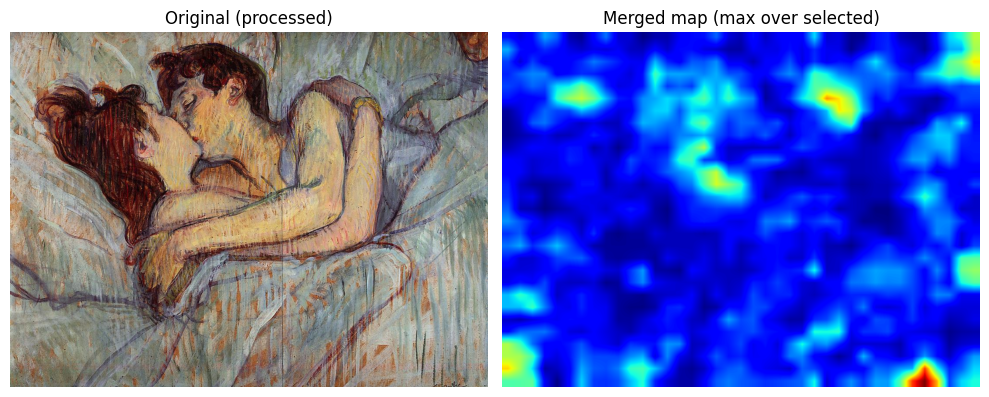

In [12]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

artist_prompt = (
    "Who made this artwork? Respond with a single JSON object and nothing "
    'else, in this exact shape: {"artist": "<the artist full name>"}.'
)

# Read from the interactive widget above
selected = result["selected_indices"]()
if not selected:
    raise RuntimeError("Select at least one token in the interactive viewer above.")

proc_img = result["proc_img"]
h, w = proc_img.shape[:2]

merged = np.maximum.reduce([result["maps"][i] for i in selected]).astype(np.float32)
merged_full = cv2.resize(merged, (w, h), interpolation=cv2.INTER_LINEAR)

print(f"Selected tokens: {selected}")
print(
    f"Merged map: shape={merged_full.shape}  min={merged_full.min():.1f}  max={merged_full.max():.1f}"
)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(proc_img)
ax[0].set_title("Original (processed)")
ax[0].axis("off")
ax[1].imshow(merged_full, cmap="jet")
ax[1].set_title("Merged map (max over selected)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

[top 10% masked]  ```json
{
  "artist": "Henri de Toulouse-Lautrec"
}
```
[top 20% masked]  ```json
{
  "artist": "Henri de Toulouse-Lautrec"
}
```
[top 30% masked]  ```json
{
  "artist": "Henri de Toulouse-Lautrec"
}
```
[top 40% masked]  ```json
{
  "artist": "Unknown"
}
```
[top 50% masked]  ```json
{
  "artist": "Unknown"
}
```
[top 60% masked]  ```json
{
  "artist": "Unknown"
}
```
[top 70% masked]  ```json
{
  "artist": "Unknown"
}
```
[top 80% masked]  ```json
{
  "artist": "Unknown"
}
```
[top 90% masked]  ```json
{
  "artist": "Unknown"
}
```


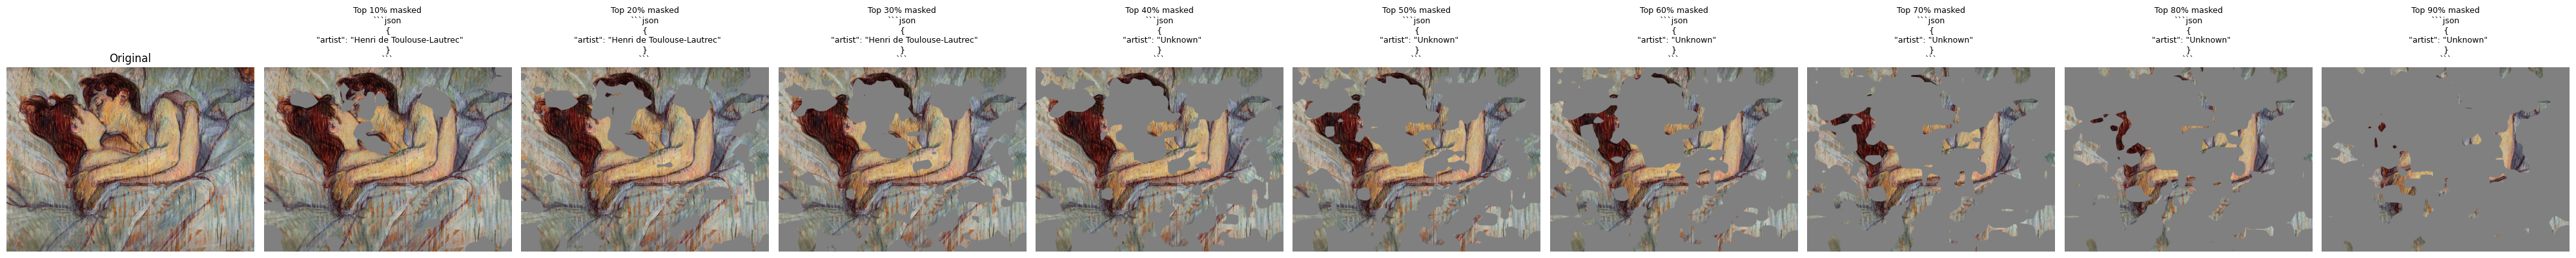


Interactive explanation on top-90%-masked image:


HTML(value='<b>Generated:</b> ```json\n{\n  "artist": "Unknown"\n}\n```')

In [13]:
MASK_COLOR = 128  # mid-grey
percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90]

masked_images = {}
answers = {}
flat = merged_full.ravel()

for p in percentages:
    # Top-p% pixels by activation -> grey mask
    thresh = np.percentile(flat, 100 - p)
    mask = merged_full >= thresh
    masked = proc_img.copy()
    masked[mask] = MASK_COLOR
    masked_images[p] = masked

    pil_img = Image.fromarray(masked)
    out = explainer.explain(image=pil_img, prompt=artist_prompt)
    answers[p] = out["text"]
    print(f"[top {p:>2}% masked]  {out['text']}")

fig, axes = plt.subplots(1, len(percentages) + 1, figsize=(4 * (len(percentages) + 1), 4))
axes[0].imshow(proc_img); axes[0].set_title("Original"); axes[0].axis("off")
for ax, p in zip(axes[1:], percentages):
    ax.imshow(masked_images[p])
    ax.set_title(f"Top {p}% masked\n{answers[p]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

# Interactive viewer on the most-masked variant
most_masked_p = percentages[-1]
print(f"\nInteractive explanation on top-{most_masked_p}%-masked image:")
result_masked = explainer.explain_interactive(
    image=Image.fromarray(masked_images[most_masked_p]),
    prompt=artist_prompt,
)

## Random-region masking baseline (LAMA-style)

Control experiment: mask the same percentages but with random contiguous regions instead of TAM-selected pixels. Following the LAMA paper, regions are drawn from thick polyline brush strokes and random rectangles — not scattered pixels — so each mask removes a few coherent chunks of the image. If TAM is doing something meaningful, the model should be hurt more by the TAM-targeted masks than by these random ones.

In [ ]:
def random_lama_mask(h, w, target_ratio, seed=None, overshoot_tol=0.02, max_iters=500):
    """LAMA-style random mask: irregular contiguous regions (thick polyline
    brush strokes + rectangles) approximately covering ``target_ratio`` of
    the image. Iterations that would push coverage past
    ``target_ratio + overshoot_tol`` are reverted so the final coverage
    lands close to the target.
    """
    rng = np.random.default_rng(seed)
    mask = np.zeros((h, w), dtype=np.uint8)
    target_px = target_ratio * h * w
    upper_px = (target_ratio + overshoot_tol) * h * w
    min_dim = min(h, w)
    t_min = max(8, min_dim // 30)
    t_max = max(t_min + 1, min_dim // 10)

    for _ in range(max_iters):
        if mask.sum() >= target_px:
            break
        prev = mask.copy()
        if rng.random() < 0.6:
            n_vertices = int(rng.integers(3, 7))
            xs = rng.integers(0, w, size=n_vertices)
            ys = rng.integers(0, h, size=n_vertices)
            pts = np.stack([xs, ys], axis=1).astype(np.int32)
            thickness = int(rng.integers(t_min, t_max))
            cv2.polylines(mask, [pts], isClosed=False, color=1,
                          thickness=thickness, lineType=cv2.LINE_8)
        else:
            rect_w = int(rng.integers(max(1, w // 12), max(2, w // 4)))
            rect_h = int(rng.integers(max(1, h // 12), max(2, h // 4)))
            x = int(rng.integers(0, max(1, w - rect_w)))
            y = int(rng.integers(0, max(1, h - rect_h)))
            cv2.rectangle(mask, (x, y), (x + rect_w, y + rect_h), 1, thickness=-1)

        if mask.sum() > upper_px:
            mask = prev  # would overshoot; try a different primitive

    return mask.astype(bool)


rand_masked_images = {}
rand_answers = {}

for p in percentages:
    m = random_lama_mask(h, w, p / 100, seed=p)
    masked = proc_img.copy()
    masked[m] = MASK_COLOR
    rand_masked_images[p] = masked

    pil_img = Image.fromarray(masked)
    out = explainer.explain(image=pil_img, prompt=artist_prompt)
    rand_answers[p] = out["text"]
    print(f"[random {p:>2}% masked]  coverage={m.mean()*100:5.1f}%  {out['text']}")

fig, axes = plt.subplots(1, len(percentages) + 1, figsize=(4 * (len(percentages) + 1), 4))
axes[0].imshow(proc_img); axes[0].set_title("Original"); axes[0].axis("off")
for ax, p in zip(axes[1:], percentages):
    ax.imshow(rand_masked_images[p])
    ax.set_title(f"Random {p}% masked\n{rand_answers[p]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

# Interactive viewer on the most-masked random variant
most_masked_p = percentages[-1]
print(f"\nInteractive explanation on random {most_masked_p}%-masked image:")
result_random_masked = explainer.explain_interactive(
    image=Image.fromarray(rand_masked_images[most_masked_p]),
    prompt=artist_prompt,
)

## Bottom-percentile masking (inverse TAM control)

Same merged map as the top-percentile experiment, but we mask the *lowest*-scored 10/20/30/40% of pixels instead of the highest. The masks come from the same TAM distribution (same kind of coverage shape, same edges of the score field), so this is an apples-to-apples comparison: if TAM is meaningful, masking the bottom should hurt the model much less than masking the top at matched coverage.

[bottom 10% masked]  coverage= 10.0%  ```json
{
  "artist": "Henri de Toulouse-Lautrec"
}
```
[bottom 20% masked]  coverage= 20.0%  {"artist": "Henri de Toulouse-Lautrec"}
[bottom 30% masked]  coverage= 30.0%  {"artist": "Henri de Toulouse-Lautrec"}
[bottom 40% masked]  coverage= 40.0%  ```json
{
  "artist": "Unknown Artist"
}
```
[bottom 50% masked]  coverage= 50.0%  ```json
{
  "artist": "Unknown Artist"
}
```
[bottom 60% masked]  coverage= 60.0%  ```json
{
  "artist": "Unknown Artist"
}
```
[bottom 70% masked]  coverage= 70.0%  ```json
{
  "artist": "Unknown Artist"
}
```
[bottom 80% masked]  coverage= 80.0%  ```json
{
  "artist": "Unknown Artist"
}
```
[bottom 90% masked]  coverage= 90.0%  ```json
{
  "artist": "Unknown"
}
```


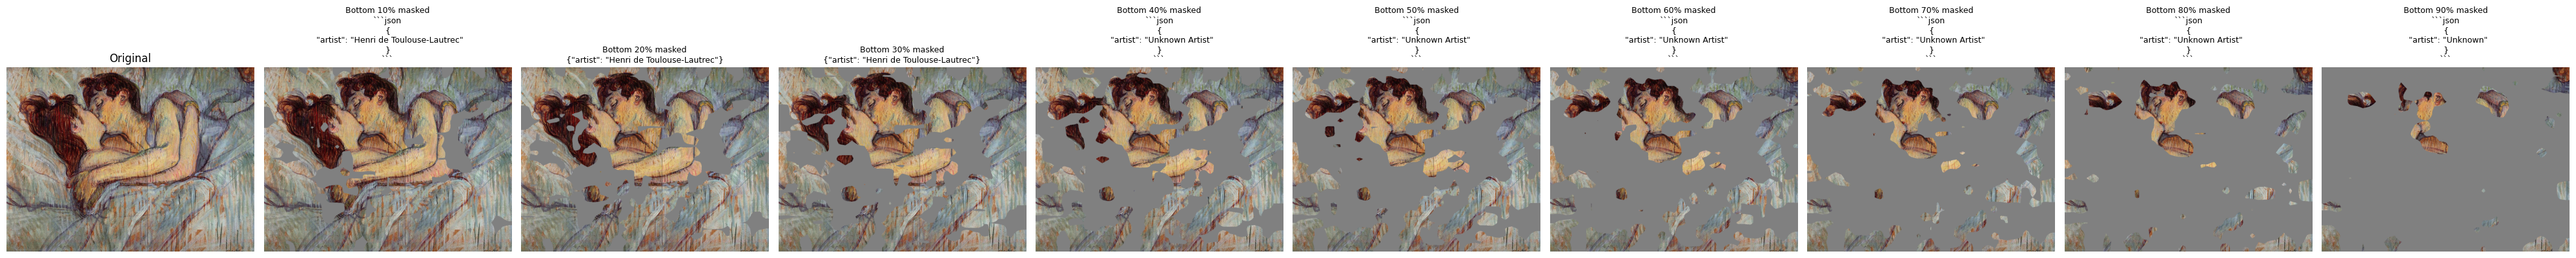


Interactive explanation on bottom-90%-masked image:


HTML(value='<b>Generated:</b> ```json\n{\n  "artist": "Unknown"\n}\n```')

In [14]:
bot_masked_images = {}
bot_answers = {}

for p in percentages:
    # Bottom-p% pixels by activation -> grey mask
    thresh = np.percentile(flat, p)
    mask = merged_full <= thresh
    masked = proc_img.copy()
    masked[mask] = MASK_COLOR
    bot_masked_images[p] = masked

    pil_img = Image.fromarray(masked)
    out = explainer.explain(image=pil_img, prompt=artist_prompt)
    bot_answers[p] = out["text"]
    print(f"[bottom {p:>2}% masked]  coverage={mask.mean()*100:5.1f}%  {out['text']}")

fig, axes = plt.subplots(1, len(percentages) + 1, figsize=(4 * (len(percentages) + 1), 4))
axes[0].imshow(proc_img); axes[0].set_title("Original"); axes[0].axis("off")
for ax, p in zip(axes[1:], percentages):
    ax.imshow(bot_masked_images[p])
    ax.set_title(f"Bottom {p}% masked\n{bot_answers[p]}", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()

# Interactive viewer on the most-masked bottom-percentile variant
most_masked_p = percentages[-1]
print(f"\nInteractive explanation on bottom-{most_masked_p}%-masked image:")
result_bottom_masked = explainer.explain_interactive(
    image=Image.fromarray(bot_masked_images[most_masked_p]),
    prompt=artist_prompt,
)